# Austrian Grand Prix - 2026 🇦🇹 | The Race

- This notebook is full post-race technical debrief of the Austrian Grandprix - 2026.
- I have tried to work with the data the best I can considering the limitations that I have faced, most significantly not having access to the telemetry of the cars.
- Hence, I have researched technical regulations for hard limits while resonable assumptions where possible to navigate the problems.

## Necessary Imports

In [1]:
# FastF1 Deps
import fastf1

# Data Deps
import pandas as pd

# Visualisation Deps
import matplotlib.pyplot as plt
from plotly.offline import init_notebook_mode

# Core Deps
from pathlib import Path
import sys
sys.path.append(str(Path("../../")))

# Source Deps
from mark_1 import DataLoader, DataPipeline, DataVisualisation
from mark_1.config import CarSpecifications, RaceStrategyConfig

# Plotly Notebook Orchestration
init_notebook_mode(connected=True)

## Notebook-Level Setup and Configurations

In [2]:
# Accessing the Current Working Directory for Absolute Root Path
REPO_ROOT_PATH = Path.cwd().parent.parent.parent

# Pathlib Path Objects for the Notebook
F1_PATH = REPO_ROOT_PATH / "F1"
F1_DATA_PATH = F1_PATH / "data"
CACHE_PATH = F1_PATH / "cache"
CACHE_PATH.mkdir(exist_ok=True)

# Adding the source scripts into the Python Execution Path
if F1_PATH not in sys.path:
    sys.path.append(str(F1_PATH))

## Loading the Event

In [3]:
# Defaulting the Requests for Caching to a Predefined path
# fastf1.Cache.clear_cache(cache_dir=str(CACHE_PATH))
fastf1.Cache.enable_cache(cache_dir=str(CACHE_PATH))

# Enabling Offline Mode
fastf1.Cache.offline_mode(enabled=True)

# The GP Event
austria_2026 = fastf1.get_event(
    year=2026,
    gp="austria"
)
print(austria_2026)

RoundNumber                                                  8
Country                                                Austria
Location                                             Spielberg
OfficialEventName    FORMULA 1 LENOVO AUSTRIAN GRAND PRIX 2026
EventDate                                  2026-06-28 00:00:00
EventName                                  Austrian Grand Prix
EventFormat                                       conventional
Session1                                            Practice 1
Session1Date                         2026-06-26 13:30:00+02:00
Session1DateUtc                            2026-06-26 11:30:00
Session2                                            Practice 2
Session2Date                         2026-06-26 17:00:00+02:00
Session2DateUtc                            2026-06-26 15:00:00
Session3                                            Practice 3
Session3Date                         2026-06-27 12:30:00+02:00
Session3DateUtc                            2026-06-27 1

In [4]:
austria_2026 = DataLoader(race_event=austria_2026)
gp_weekend = austria_2026.load_data()

core           INFO 	Loading data for Austrian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '16', '44', '12', '3', '1', '81', '6', '30', '41', '10', '5', '87', '27', '31', '43', '55', '23', '11', '77', '14', '18']
core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	U

In [5]:
# Decompiling the Data
race = gp_weekend.race_session

In [6]:
# Loading the Performance data from Quali
quali_performance = pd.read_csv(F1_DATA_PATH / "quali_performance_austria.csv")
quali_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,RearAEI,BalancedAEI,FrontAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,ANT,16.477,29.666,19.998,66.414,319.0,229.0,281.0,321.0,0.275159,0.197858,0.243164,38.123457,1507.067901,717.197531,2.313738,50.801183,35.863463,1.006270,9.562500
1,HAM,16.521,29.690,20.197,66.408,310.0,221.0,279.0,307.0,0.278845,0.199492,0.249956,-55.130093,1352.429630,488.695062,-3.336971,45.551688,24.196418,0.990323,9.918963
2,PIA,16.600,29.742,20.133,66.511,309.0,229.0,277.0,316.0,0.268745,0.200475,0.241862,130.304784,1412.206019,688.813426,7.849686,47.481878,34.213154,1.022654,9.792000
3,RUS,16.424,29.620,20.042,66.113,316.0,227.0,283.0,323.0,0.271758,0.195218,0.242844,133.223611,1572.592593,721.962963,8.111520,53.092255,36.022501,1.022152,9.577465
4,VER,16.501,29.719,20.255,66.475,317.0,224.0,275.0,316.0,0.277357,0.196250,0.238670,-18.853241,1479.666667,721.694907,-1.142551,49.788575,35.630457,0.996845,9.668246


## Data Engineering

<img src="../../../assets/circuit_maps/austria_map.avif">

In [7]:
# Instantiating the Data Pipeline
data_pipe = DataPipeline(circuit="austria")

# Full Laps Frame
assert race, "Race was not loaded"
race_laps_full = race.laps

# Total no of laps in the race
max_laps = race.laps["LapNumber"].max()

# Drop columns
drop_cols = [
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", 
    "DeletedReason", "FastF1Generated", "IsAccurate",
    "LapStartDate", "LapStartTime"
]

# Filtered Laps
filtered_race_laps = race_laps_full.drop(drop_cols, axis=1)

# Calculating the Driver Deltas
filtered_race_laps = data_pipe.get_traffic_delta(laps_frame=filtered_race_laps)

# Rounding down to the top runners
top_5_drivers = race.results.iloc[:5]["Abbreviation"]
filtered_race_laps = filtered_race_laps.pick_drivers(top_5_drivers.to_list())
filtered_race_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta
145,0 days 00:58:24.877000,ANT,12,0 days 00:01:16.931000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:33.513000,...,310.0,False,MEDIUM,1.0,True,Mercedes,1,4.0,False,0.405
146,0 days 00:59:39.093000,ANT,12,0 days 00:01:14.216000,2.0,1.0,NaT,NaT,0 days 00:00:17.866000,0 days 00:00:33.687000,...,278.0,False,MEDIUM,2.0,True,Mercedes,1,5.0,True,0.479
147,0 days 01:00:51.661000,ANT,12,0 days 00:01:12.568000,3.0,1.0,NaT,NaT,0 days 00:00:17.354000,0 days 00:00:32.791000,...,302.0,True,MEDIUM,3.0,True,Mercedes,1,5.0,False,0.601
148,0 days 01:02:03.775000,ANT,12,0 days 00:01:12.114000,4.0,1.0,NaT,NaT,0 days 00:00:17.393000,0 days 00:00:32.509000,...,302.0,True,MEDIUM,4.0,True,Mercedes,1,5.0,False,0.744
149,0 days 01:03:15.943000,ANT,12,0 days 00:01:12.168000,5.0,1.0,NaT,NaT,0 days 00:00:17.236000,0 days 00:00:32.605000,...,300.0,False,MEDIUM,5.0,True,Mercedes,1,5.0,False,0.660


In [8]:
# Transforming all the timedelta objects
get_seconds = pd.Timedelta.total_seconds

filtered_race_laps["LapTime"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["LapTime"]),
    axis=1
)
filtered_race_laps["Sector1Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector1Time"]),
    axis=1
)
filtered_race_laps["Sector2Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector2Time"]),
    axis=1
)
filtered_race_laps["Sector3Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector3Time"]),
    axis=1
)

# Picking all the green flag laps without boxing
filtered_race_laps_wo = (
    filtered_race_laps
    .pick_wo_box()
    .pick_track_status(status="1")
    .copy()
)
filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta
145,0 days 00:58:24.877000,ANT,12,76.931,1.0,1.0,NaT,NaT,NaN,33.513,...,310.0,False,MEDIUM,1.0,True,Mercedes,1,4.0,False,0.405
146,0 days 00:59:39.093000,ANT,12,74.216,2.0,1.0,NaT,NaT,17.866,33.687,...,278.0,False,MEDIUM,2.0,True,Mercedes,1,5.0,True,0.479
147,0 days 01:00:51.661000,ANT,12,72.568,3.0,1.0,NaT,NaT,17.354,32.791,...,302.0,True,MEDIUM,3.0,True,Mercedes,1,5.0,False,0.601
148,0 days 01:02:03.775000,ANT,12,72.114,4.0,1.0,NaT,NaT,17.393,32.509,...,302.0,True,MEDIUM,4.0,True,Mercedes,1,5.0,False,0.744
149,0 days 01:03:15.943000,ANT,12,72.168,5.0,1.0,NaT,NaT,17.236,32.605,...,300.0,False,MEDIUM,5.0,True,Mercedes,1,5.0,False,0.660


### Engineering the Aero Features

In [9]:
# Sector - 1: Rear Axle Load
filtered_race_laps_wo.loc[:, "RearAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 2: Balanced Load
filtered_race_laps_wo.loc[:, "BalancedAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 3: Front Axle Load
filtered_race_laps_wo.loc[:, "FrontAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta,RearAEI,BalancedAEI,FrontAEI
145,0 days 00:58:24.877000,ANT,12,76.931,1.0,1.0,NaT,NaT,NaN,33.513,...,1.0,True,Mercedes,1,4.0,False,0.405,NaN,0.171348,0.252879
146,0 days 00:59:39.093000,ANT,12,74.216,2.0,1.0,NaT,NaT,17.866,33.687,...,2.0,True,Mercedes,1,5.0,True,0.479,0.269210,0.191021,0.276744
147,0 days 01:00:51.661000,ANT,12,72.568,3.0,1.0,NaT,NaT,17.354,32.791,...,3.0,True,Mercedes,1,5.0,False,0.601,0.269551,0.179760,0.254823
148,0 days 01:02:03.775000,ANT,12,72.114,4.0,1.0,NaT,NaT,17.393,32.509,...,4.0,True,Mercedes,1,5.0,False,0.744,0.276142,0.182212,0.259031
149,0 days 01:03:15.943000,ANT,12,72.168,5.0,1.0,NaT,NaT,17.236,32.605,...,5.0,True,Mercedes,1,5.0,False,0.660,0.282343,0.181991,0.258520


### Engineering the Kinetic Energy Features

In [10]:
# Sector - 1
filtered_race_laps_wo.loc[:, "KineticEnergyS1_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 2
filtered_race_laps_wo.loc[:, "KineticEnergyS2_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 3
filtered_race_laps_wo.loc[:, "KineticEnergyS3_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TrackStatus,Position,Deleted,TrafficDelta,RearAEI,BalancedAEI,FrontAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ
145,0 days 00:58:24.877000,ANT,12,76.931,1.0,1.0,NaT,NaT,NaN,33.513,...,1,4.0,False,0.405,NaN,0.171348,0.252879,109.724074,1634.870833,322.738889
146,0 days 00:59:39.093000,ANT,12,74.216,2.0,1.0,NaT,NaT,17.866,33.687,...,1,5.0,True,0.479,0.269210,0.191021,0.276744,-83.543981,1062.333951,-220.311883
147,0 days 01:00:51.661000,ANT,12,72.568,3.0,1.0,NaT,NaT,17.354,32.791,...,1,5.0,False,0.601,0.269551,0.179760,0.254823,53.700463,1489.048611,246.015432
148,0 days 01:02:03.775000,ANT,12,72.114,4.0,1.0,NaT,NaT,17.393,32.509,...,1,5.0,False,0.744,0.276142,0.182212,0.259031,-90.692130,1476.926543,211.585185
149,0 days 01:03:15.943000,ANT,12,72.168,5.0,1.0,NaT,NaT,17.236,32.605,...,1,5.0,False,0.660,0.282343,0.181991,0.258520,-163.245833,1453.188735,192.970216


### Engineering the Power Features

In [11]:
# Sector - 1
filtered_race_laps_wo.loc[:, "PowerS1_KW"] = data_pipe.get_power_expenditure(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 2
filtered_race_laps_wo.loc[:, "PowerS2_KW"] = data_pipe.get_power_expenditure(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 3
filtered_race_laps_wo.loc[:, "PowerS3_KW"] = data_pipe.get_power_expenditure(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TrafficDelta,RearAEI,BalancedAEI,FrontAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW
145,0 days 00:58:24.877000,ANT,12,76.931,1.0,1.0,NaT,NaT,NaN,33.513,...,0.405,NaN,0.171348,0.252879,109.724074,1634.870833,322.738889,NaN,48.783184,14.460923
146,0 days 00:59:39.093000,ANT,12,74.216,2.0,1.0,NaT,NaT,17.866,33.687,...,0.479,0.269210,0.191021,0.276744,-83.543981,1062.333951,-220.311883,-4.676144,31.535428,-9.721214
147,0 days 01:00:51.661000,ANT,12,72.568,3.0,1.0,NaT,NaT,17.354,32.791,...,0.601,0.269551,0.179760,0.254823,53.700463,1489.048611,246.015432,3.094414,45.410284,10.971566
148,0 days 01:02:03.775000,ANT,12,72.114,4.0,1.0,NaT,NaT,17.393,32.509,...,0.744,0.276142,0.182212,0.259031,-90.692130,1476.926543,211.585185,-5.214289,45.431313,9.525715
149,0 days 01:03:15.943000,ANT,12,72.168,5.0,1.0,NaT,NaT,17.236,32.605,...,0.660,0.282343,0.181991,0.258520,-163.245833,1453.188735,192.970216,-9.471213,44.569506,8.642908


### Engineering the Fuel and Pace Features

In [12]:
# Instances of all the configs
car_spec = CarSpecifications()
race_spec = RaceStrategyConfig()

In [13]:
# Engineering all the pace features using the pipeline
driver_fuel_flow = {}

mean_race_laps = data_pipe.get_mean_race_laps(
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

effective_fuel_load = data_pipe.get_effective_fuel_load(
    max_fuel_load_in_kg=car_spec.MAX_FUEL_LOAD_IN_KG,
    fuel_sample_limit=race_spec.FUEL_SAMPLE_LIMIT,
    fuel_strat=race_spec.FUEL_STRAT
)

for _, row in mean_race_laps.iterrows():
    fuel_flow = data_pipe.get_effective_fuel_flow(
        effective_fuel_load=effective_fuel_load,
        avg_laptime=row["LapTime"],
        race_laps=max_laps
    )
    driver_fuel_flow[row["Driver"]] = fuel_flow

driver_fuel_flow

{'ANT': np.float64(12.154540879469884),
 'HAM': np.float64(12.125693385647814),
 'PIA': np.float64(12.107549561107627),
 'RUS': np.float64(12.160890761331425),
 'VER': np.float64(12.15625439415075)}

In [14]:
# LapFuelBurn: Fuel burnt over a single lap based on laptime
filtered_race_laps_wo.loc[:, "LapFuelBurn"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_lap_fuel_burn(
        laptime=x["LapTime"],
        effective_fuel_flow=driver_fuel_flow[x["Driver"]]
    ), 
    axis=1
)

# CumulativeFuelBurn: The fuel burnt over the race distance based on laptimes
filtered_race_laps_wo.loc[:, "CumulativeFuelBurn"] = (
    filtered_race_laps_wo
    .groupby("Driver")["LapFuelBurn"]
    .cumsum()
)

# LapFuelPenality: Zero-Fuel Pace for each race lap based on the cumulative fuel burn offset
filtered_race_laps_wo.loc[:, "LapFuelPenality"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_lap_fuel_penality(
        cumulative_fuel_burn=x["CumulativeFuelBurn"],
        effective_fuel_load=effective_fuel_load
    ),
    axis=1
)

# FuelAwareLapTime: Final Zero-Fuel laptime within the assumed parameters
filtered_race_laps_wo["FuelAwareLapTime"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_fuel_aware_laptime(
        laptime=x["LapTime"], 
        fuel_penality=x["LapFuelPenality"]
    ),
    axis=1
)
filtered_race_laps_wo.tail()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,LapFuelBurn,CumulativeFuelBurn,LapFuelPenality,FuelAwareLapTime
1264,0 days 02:19:17.883000,PIA,81,71.937,67.0,3.0,NaT,NaT,17.494,32.364,...,-91.585648,1531.163117,213.729630,-5.235261,47.310688,9.680222,0.870981,50.631460,0.341056,71.595944
1265,0 days 02:20:29.657000,PIA,81,71.774,68.0,3.0,NaT,NaT,17.339,32.314,...,-91.585648,1531.163117,265.821759,-5.282061,47.383893,12.016715,0.869007,51.500467,0.314986,71.459014
1266,0 days 02:21:42.166000,PIA,81,72.509,69.0,3.0,NaT,NaT,17.343,32.514,...,-74.817284,1683.984568,394.458642,-4.313976,51.792599,17.413855,0.877906,52.378373,0.288649,72.220351
1267,0 days 02:22:55.231000,PIA,81,73.065,70.0,3.0,NaT,NaT,17.415,32.973,...,-56.202315,1865.219907,430.318519,-3.227236,56.568098,18.975990,0.884638,53.263011,0.262110,72.802890
1268,0 days 02:24:07.734000,PIA,81,72.503,71.0,3.0,NaT,NaT,17.583,32.631,...,-127.802932,1507.067901,229.604475,-7.268551,46.185158,10.301246,0.877834,54.140845,0.235775,72.267225


In [15]:
max_fuel_burns = filtered_race_laps_wo.groupby("Driver")["CumulativeFuelBurn"].last().reset_index()

# Sanity Check for Fuel Load
print(f"Effective Fuel Load: {effective_fuel_load}")

print("\nDriver | Max Fuel Burn")
for _, row in max_fuel_burns.iterrows():
    print(row["Driver"], " | ", row["CumulativeFuelBurn"])

Effective Fuel Load: 62

Driver | Max Fuel Burn
ANT  |  56.76056338028169
HAM  |  54.140845070422536
PIA  |  54.14084507042253
RUS  |  54.14084507042253
VER  |  54.140845070422536


## Data Visualisation

In [16]:
# Instantiating the Data Visualisation Handle
assert race is not None, "The race session wasn't loaded"

data_vis = DataVisualisation(
    session=race,
    driver_names=top_5_drivers.to_list(),
    circuit="austria"
)

req            INFO 	Using cached data for driver_info


### Simple Tyre Degradation Plots

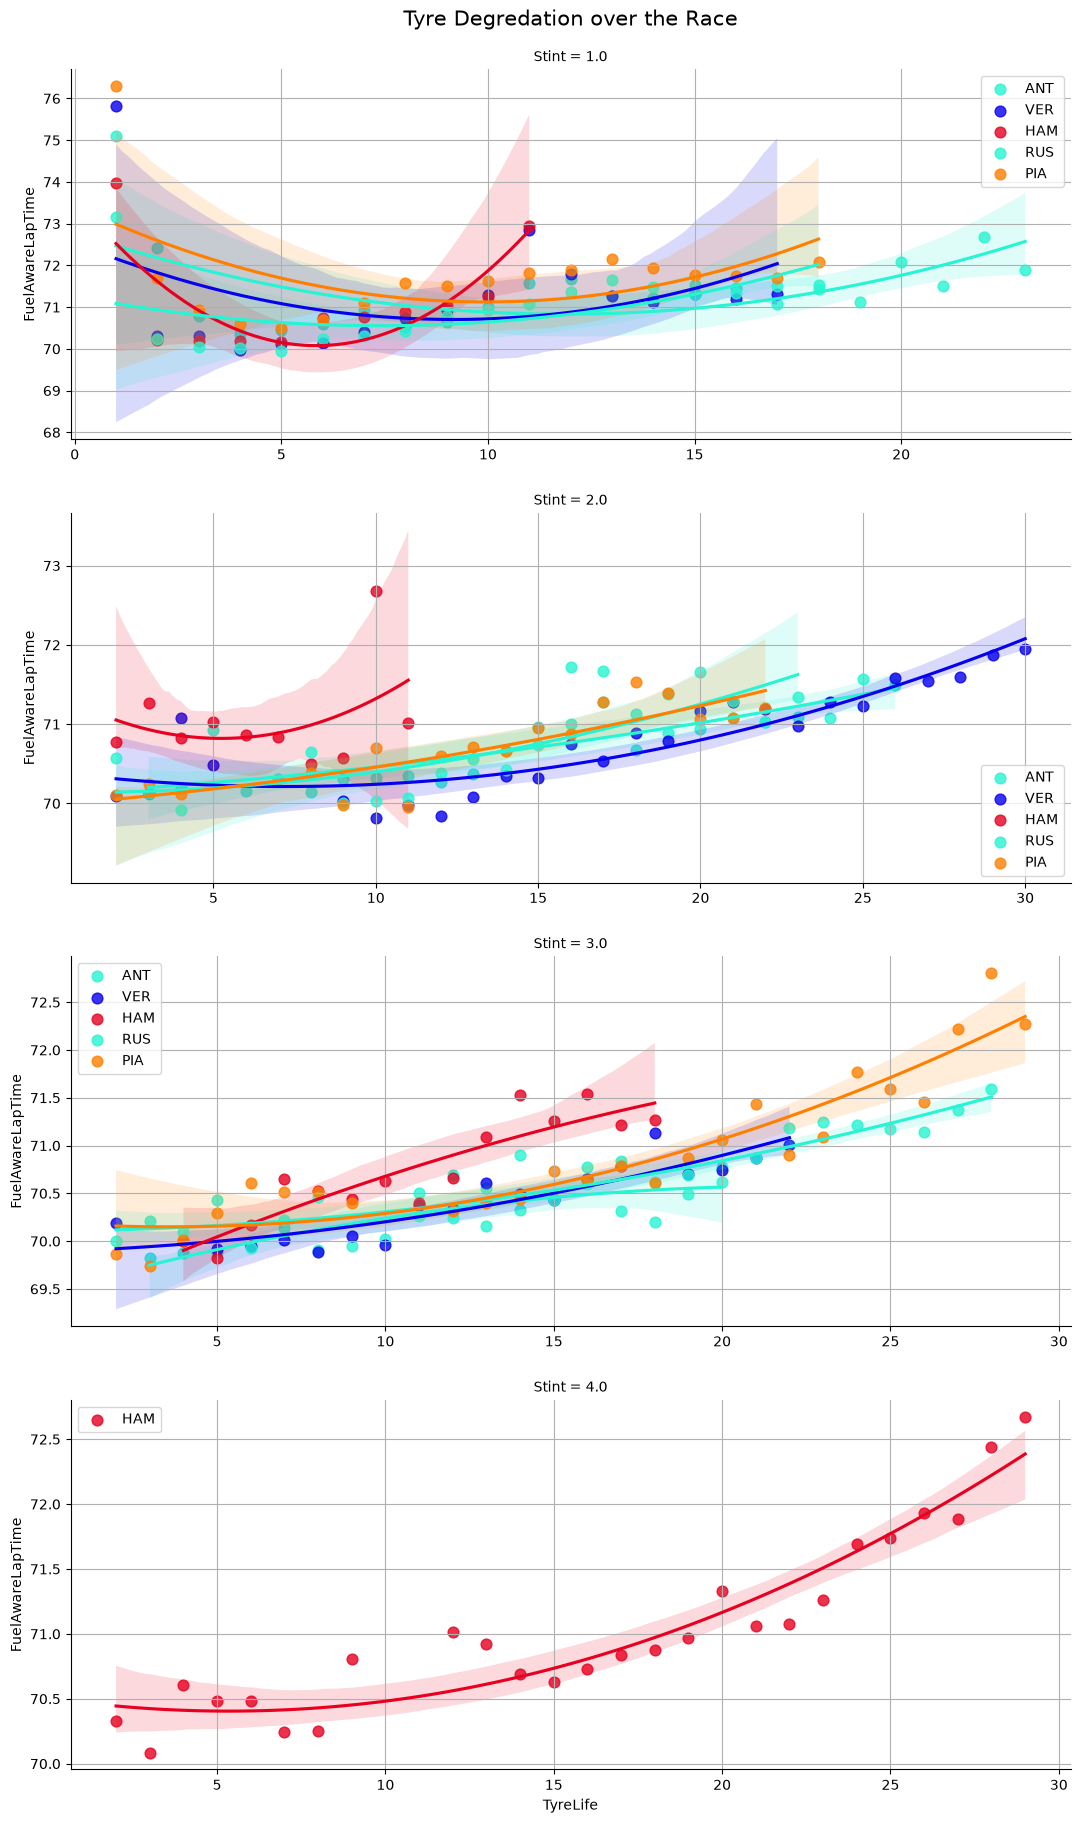

In [17]:
pace_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="FuelAwareLapTime",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

pace_deg_grid.figure.suptitle(
    "Tyre Degredation over the Race",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.95, hspace=0.2)
plt.show()

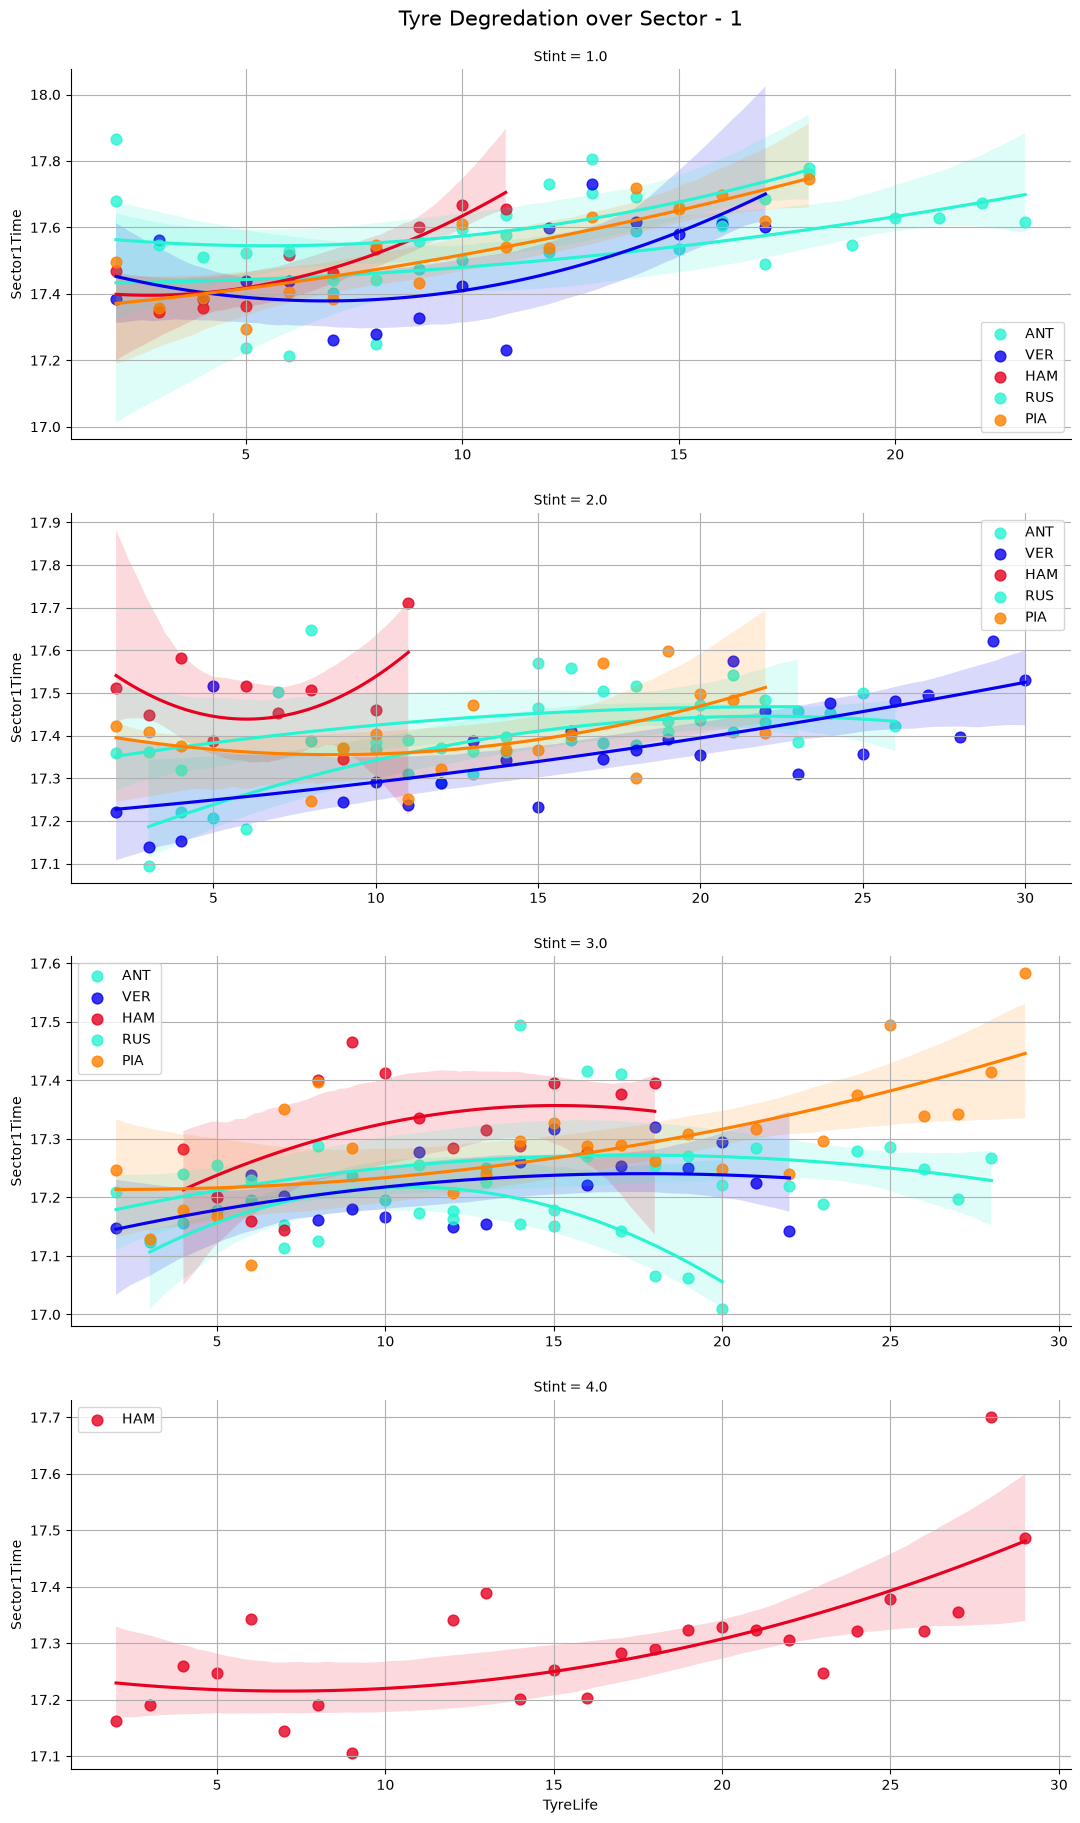

In [18]:
sector1_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector1Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector1_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 1",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.95, hspace=0.2)
plt.show()

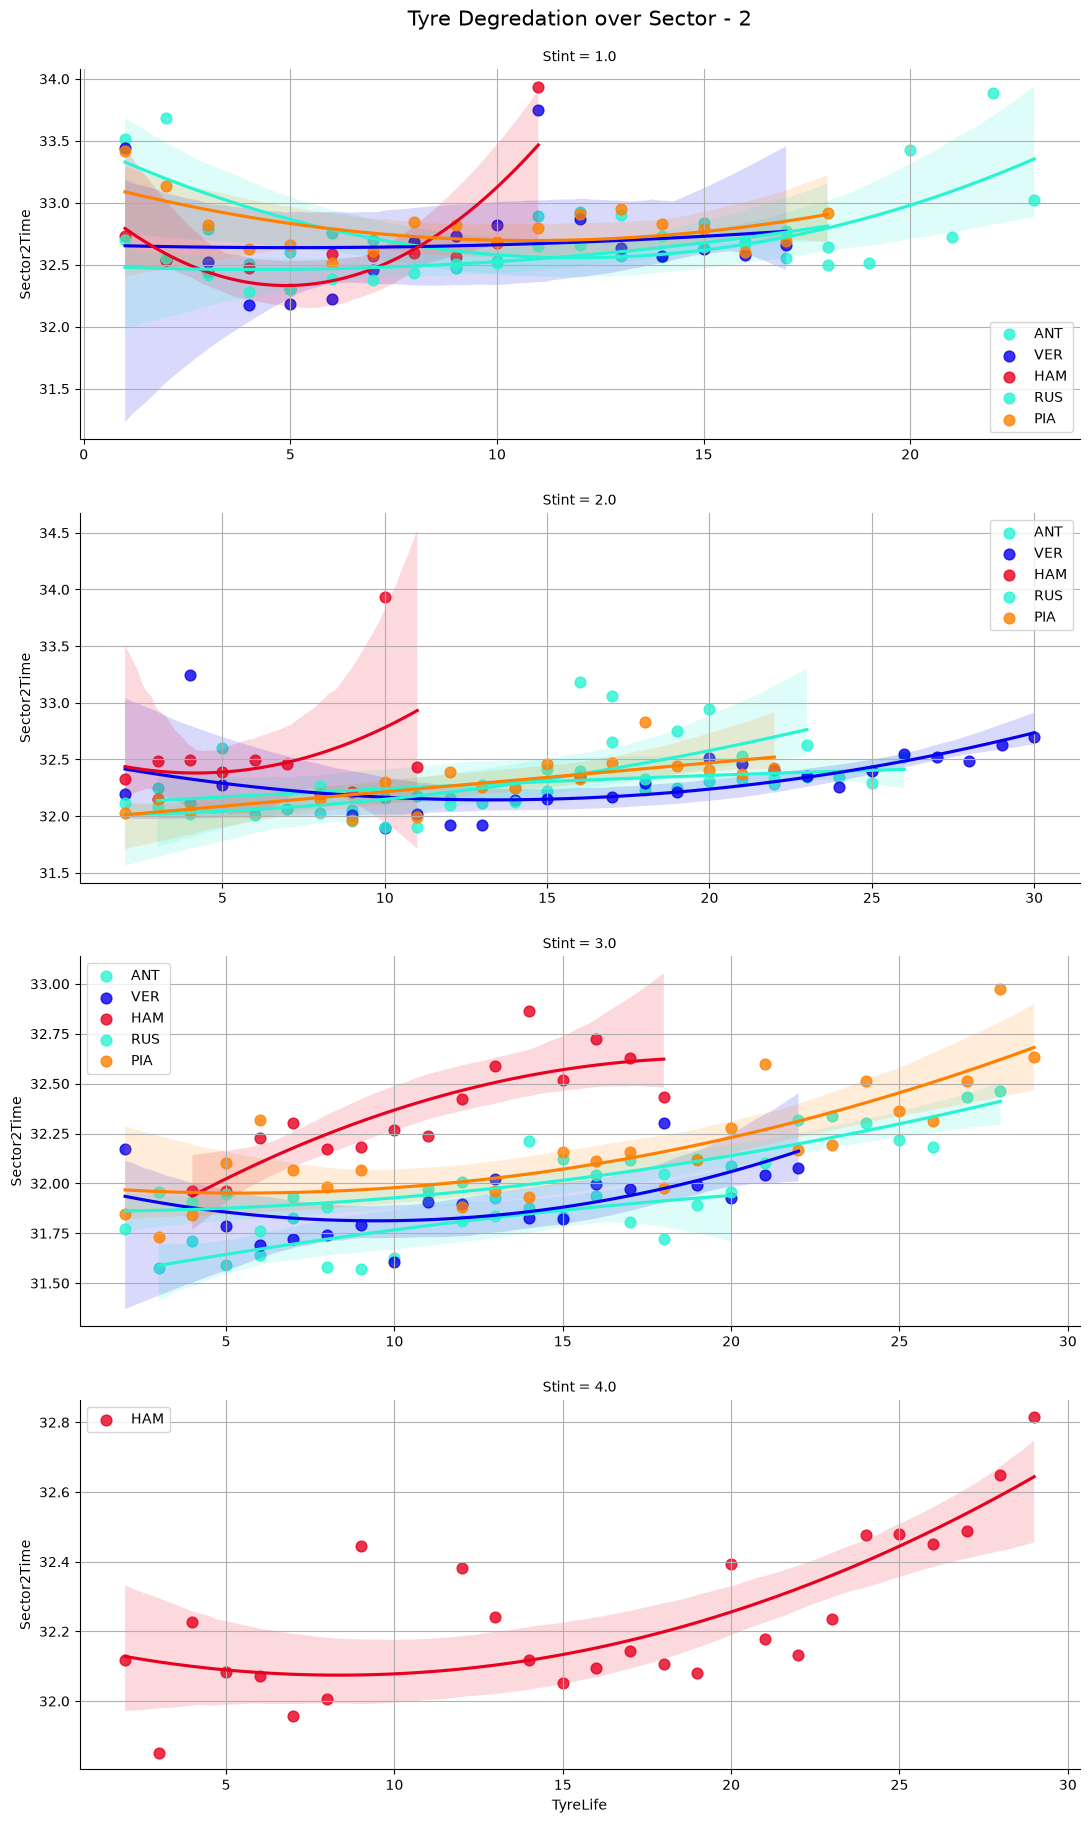

In [19]:
sector2_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector2Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector2_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 2",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.95, hspace=0.2)
plt.show()

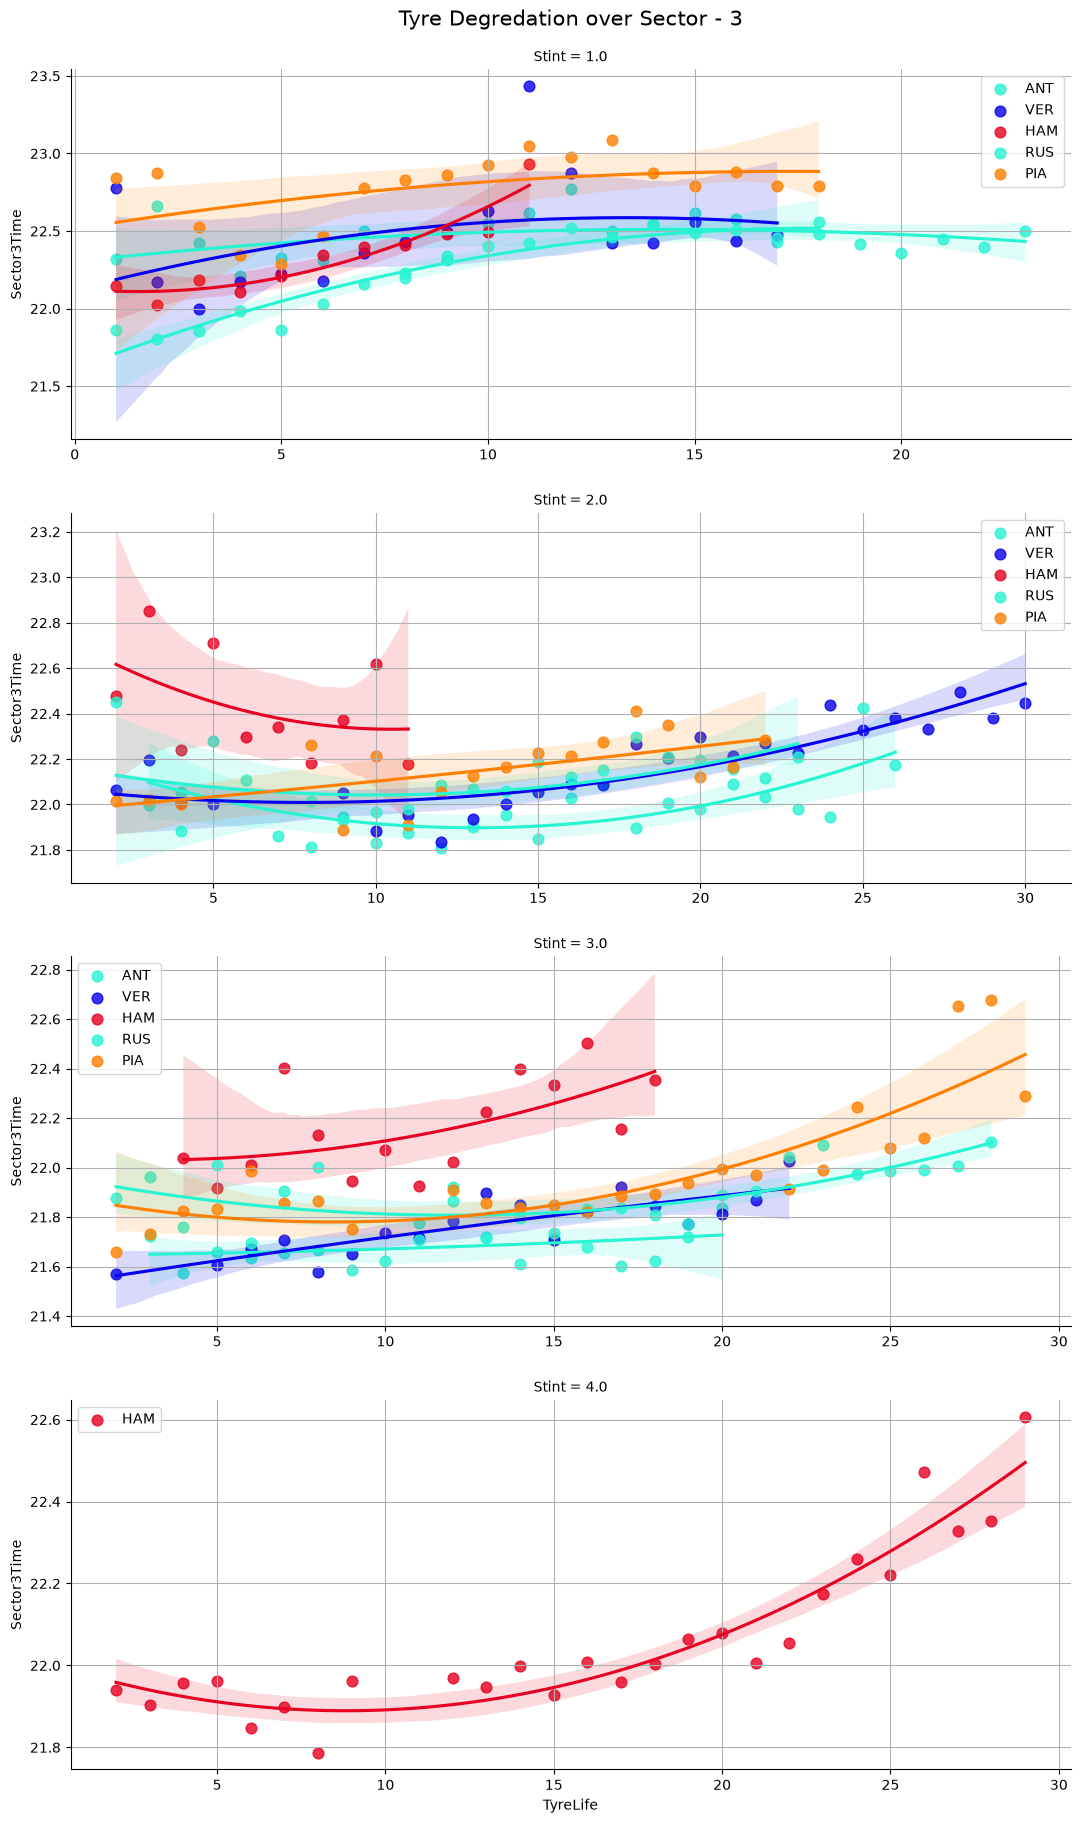

In [20]:
sector3_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector3Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector3_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 3",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.95, hspace=0.2)
plt.show()

### Raw Pace Plots

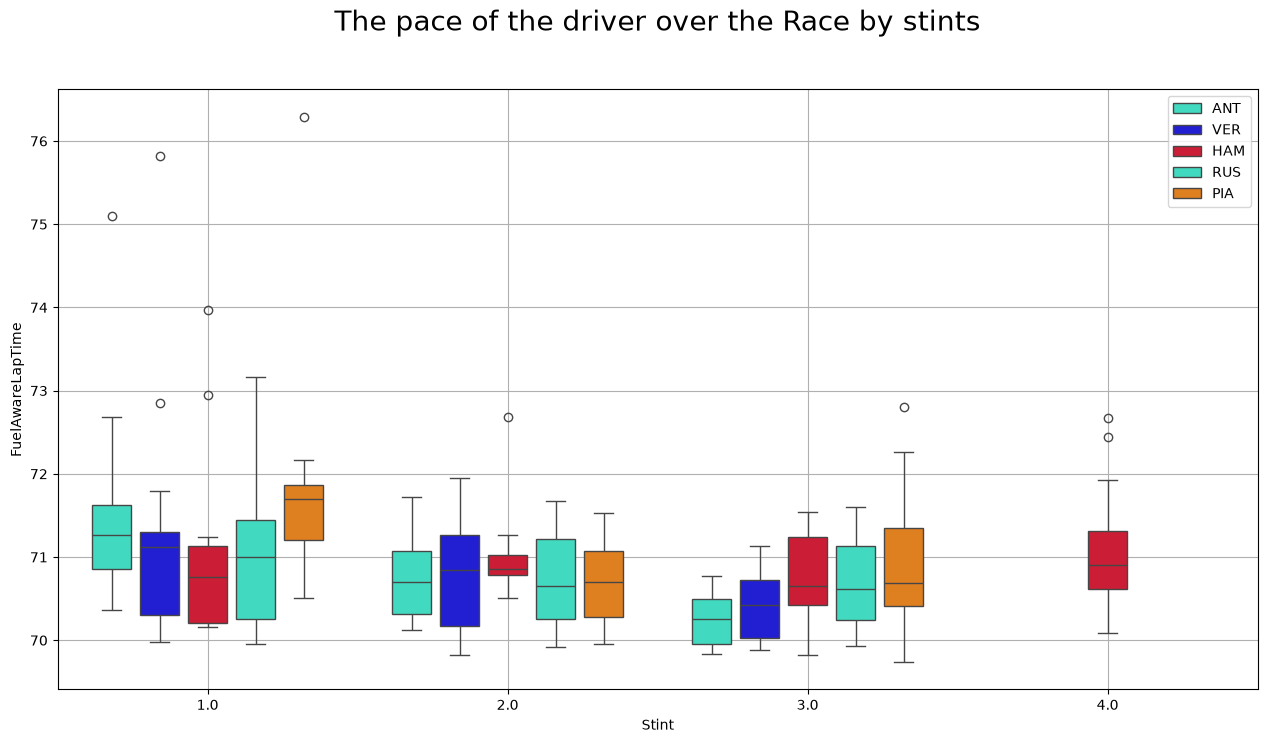

In [21]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="FuelAwareLapTime",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver over the Race by stints",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

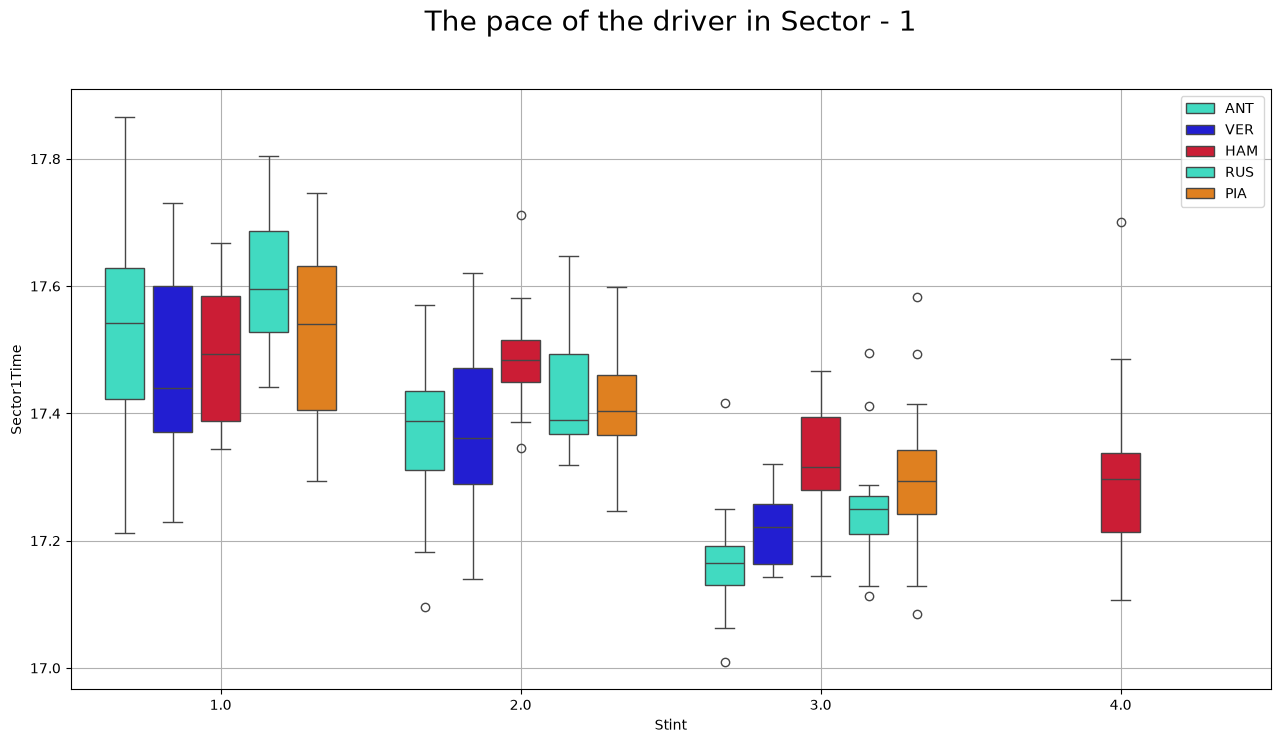

In [22]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector1Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 1",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

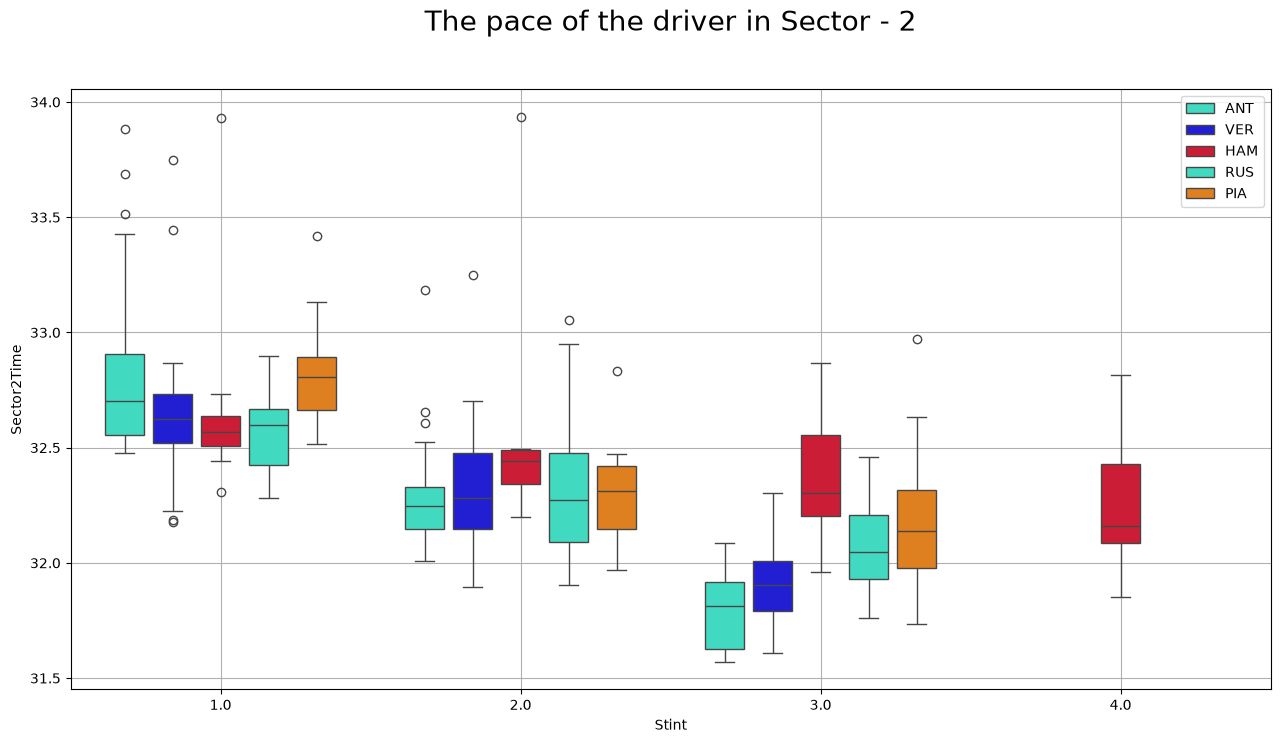

In [23]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector2Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 2",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

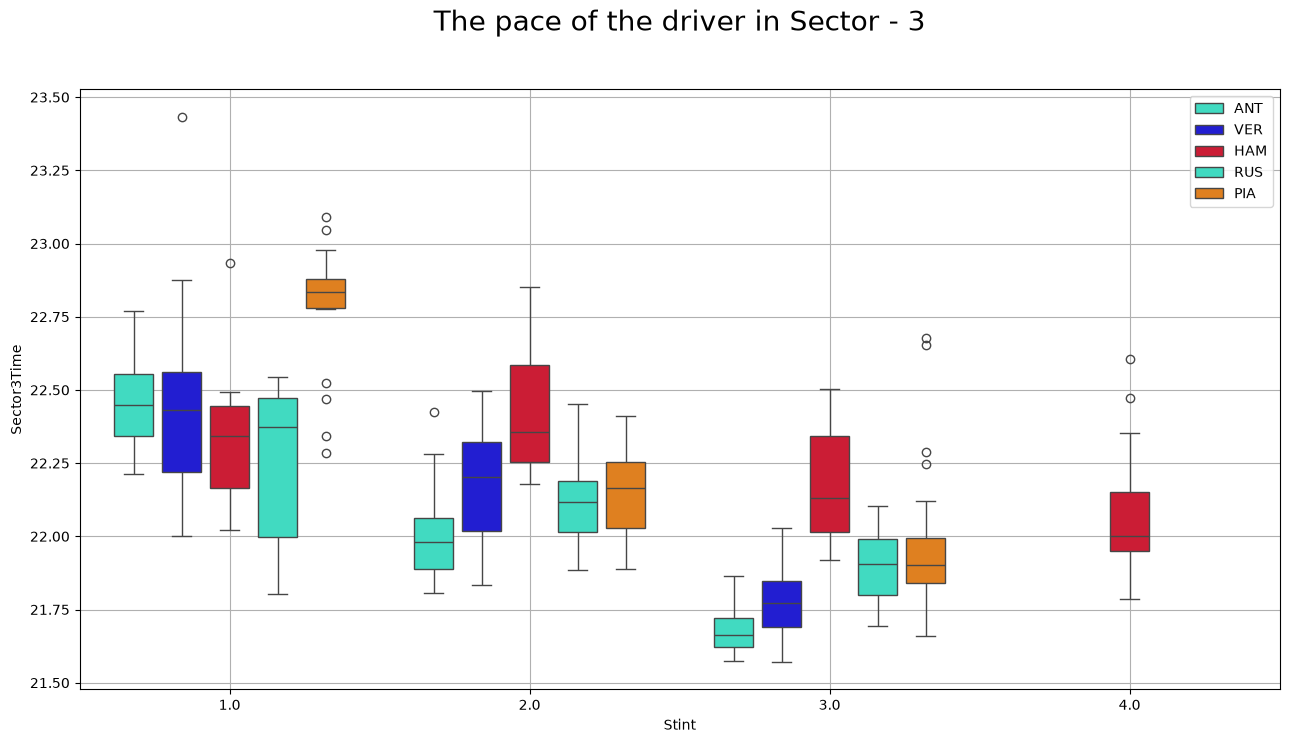

In [24]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector3Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 3",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

### KE Retention Plots

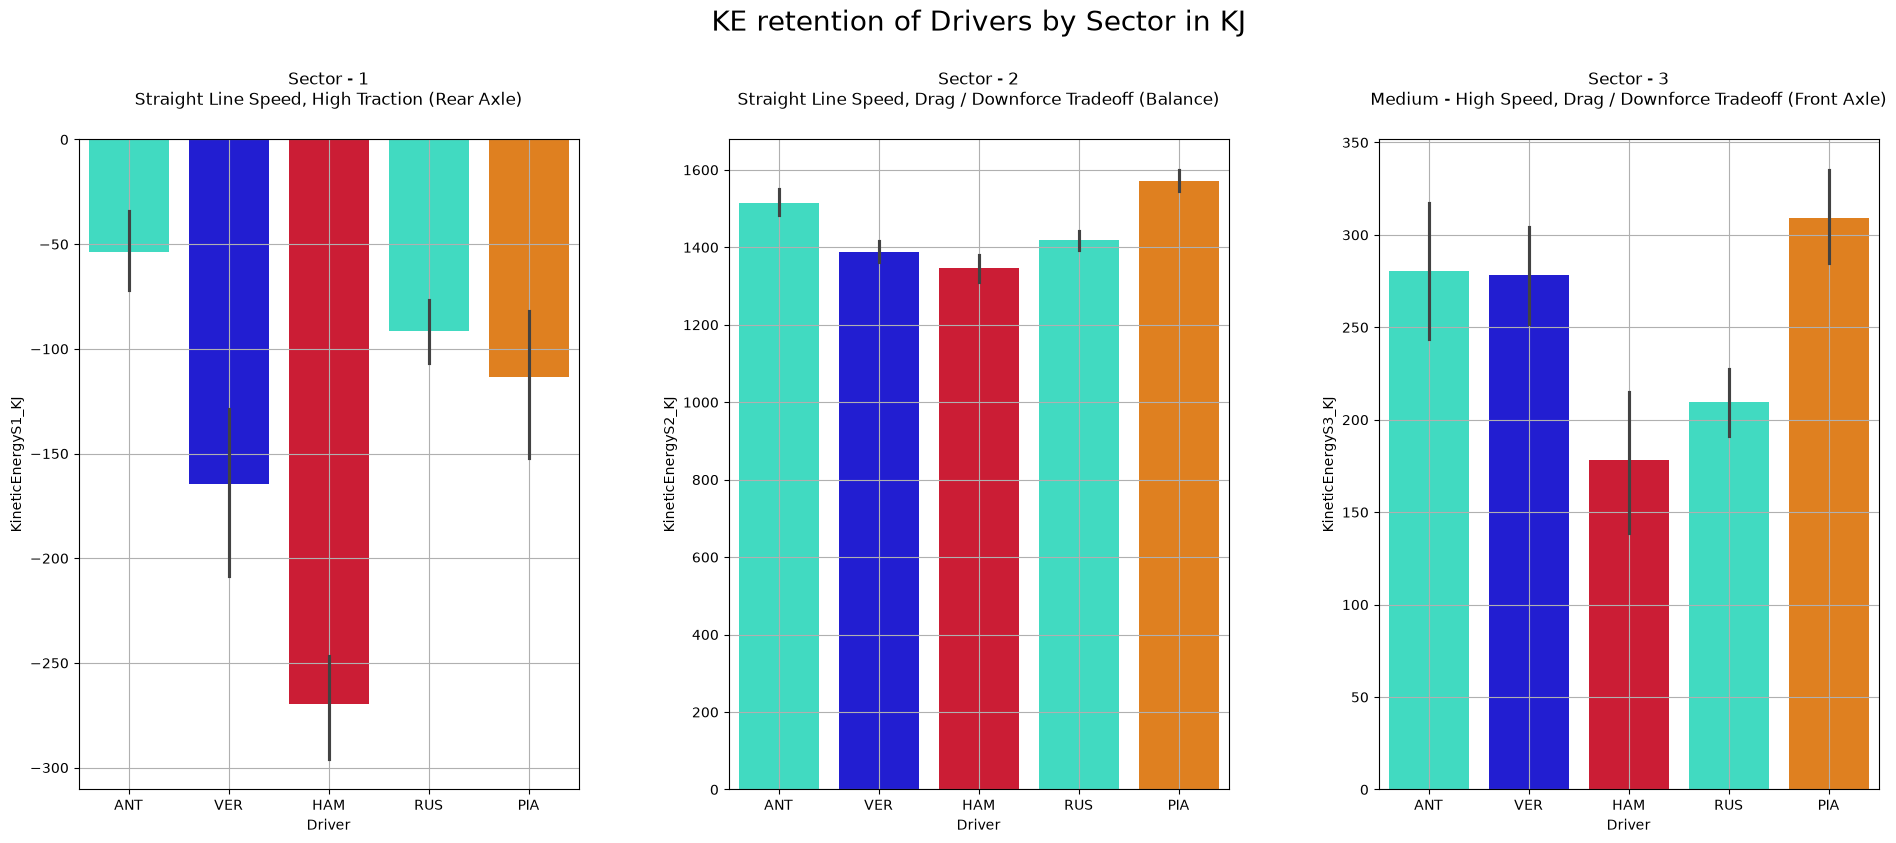

In [25]:
ke_grid = data_vis.create_bar_plots(
    nrows=1,
    ncols=3,
    figsize=(30, 10),
    data=filtered_race_laps_wo,
    hue="Driver",
    plot_kind="ke"
)

ke_grid.suptitle(
    t="KE retention of Drivers by Sector in KJ",
    fontsize=20
)
plt.subplots_adjust(
    left=0.2, right=0.8, bottom=0.2, top=0.85, wspace=0.3
)
plt.show()

**Important**
- The signifance of the above KE trends has been discussed deeper in the [Quali Notebook](./austria_quali.ipynb)
- Please look into the quali notebook to understand the reason for -ve bar in Sector - 1.

### Power Deployment Plots

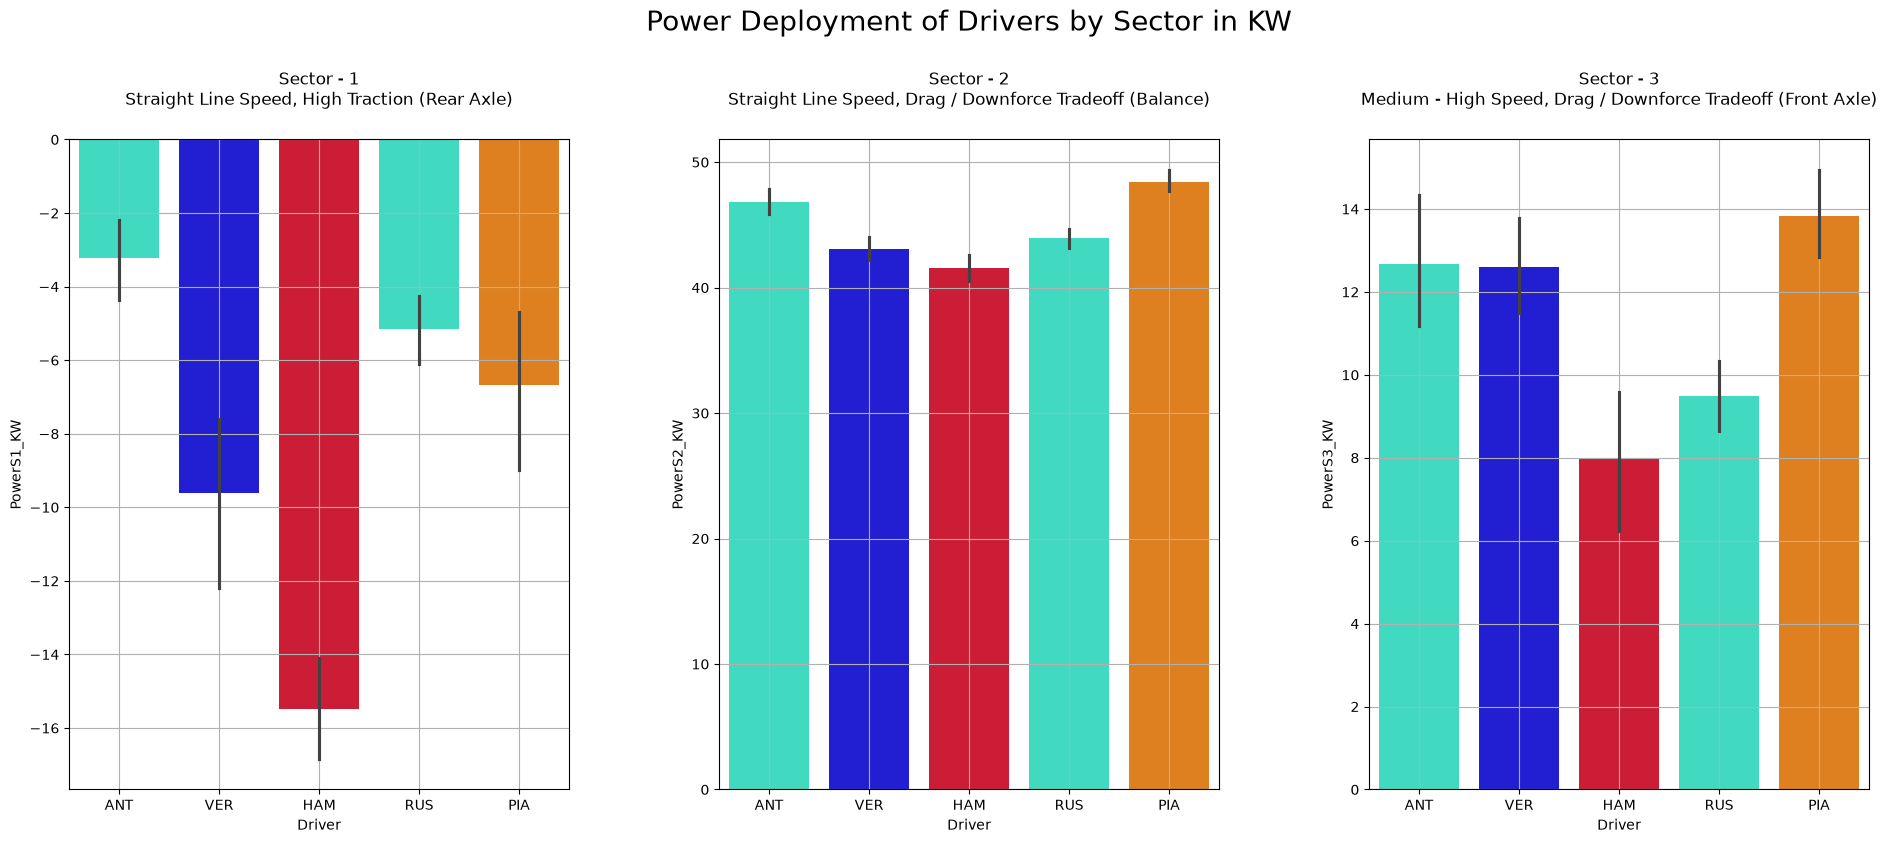

In [26]:
ke_grid = data_vis.create_bar_plots(
    nrows=1,
    ncols=3,
    figsize=(30, 10),
    data=filtered_race_laps_wo,
    hue="Driver",
    plot_kind="power"
)

ke_grid.suptitle(
    t="Power Deployment of Drivers by Sector in KW",
    fontsize=20
)
plt.subplots_adjust(
    left=0.2, right=0.8, bottom=0.2, top=0.85, wspace=0.3
)
plt.show()

### Quali Trim vs Race Trim

In [27]:
# Generating all the features
race_performance = data_pipe.get_mean_race_laps(
    laps_frame=filtered_race_laps,
    drivers=top_5_drivers.to_list()
)

# ================ Aero Features ================
race_performance.loc[:, "RearAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI1"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector1Time"],
        purple_sector_time=race_performance["Sector1Time"].min()
    ),
    axis=1
)
race_performance.loc[:, "BalancedAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI2"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector2Time"],
        purple_sector_time=race_performance["Sector2Time"].min()
    ),
    axis=1
)
race_performance.loc[:, "FrontAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedFL"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector3Time"],
        purple_sector_time=race_performance["Sector3Time"].min()
    ),
    axis=1
)

# ================ Kinetic Energy Features ================
race_performance.loc[:, "KineticEnergyS1_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI1"], 
        v2=x["SpeedST"]
    ),
    axis=1
)
race_performance.loc[:, "KineticEnergyS2_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI2"], 
        v2=x["SpeedST"]
    ),
    axis=1
)
race_performance.loc[:, "KineticEnergyS3_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedFL"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# ================ Power Features ================
race_performance["PowerS1_KW"] = (
    race_performance["KineticEnergyS1_KJ"] / 
    race_performance["Sector1Time"]
)
race_performance["PowerS2_KW"] = (
    race_performance["KineticEnergyS2_KJ"] / 
    race_performance["Sector2Time"]
)
race_performance["PowerS3_KW"] = (
    race_performance["KineticEnergyS3_KJ"] / 
    race_performance["Sector3Time"]
)

# ================ Auxiliary Features ================
# ERS Clipping
race_performance["ERS_Clipping"] = race_performance["SpeedST"] / race_performance["SpeedI1"]

# Acceleration Time
race_performance.loc[:, "AccelerationTime"] = race_performance.apply(
    lambda x: data_pipe.get_delta_acceleration_time(
        v1=x["SpeedI1"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

race_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,RearAEI,BalancedAEI,FrontAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,ANT,18.083143,32.631352,22.481958,73.238944,304.394366,203.746479,286.434783,301.450704,0.279248,0.187468,0.263941,-53.116790,1470.132807,262.922065,-2.937365,45.052770,11.694803,0.990329,10.101592
1,HAM,18.289914,32.691141,22.564535,73.582704,308.295775,203.323944,284.470588,293.492958,0.287211,0.191800,0.268253,-265.320448,1334.246235,155.311409,-14.506380,40.813695,6.882987,0.951985,10.169682
2,PIA,18.125829,32.700465,22.639197,73.518141,309.084507,201.225352,285.594203,303.183099,0.281266,0.183701,0.259845,-107.616598,1531.739405,308.440881,-5.937196,46.841518,13.624197,0.980907,9.995629
3,RUS,18.003029,32.655831,22.517817,73.210972,302.633803,204.323944,282.942029,295.929577,0.284071,0.191363,0.265164,-119.520128,1364.880538,223.919406,-6.638890,41.795921,9.944099,0.977847,10.224481
4,VER,18.048357,32.583014,22.554648,73.233662,306.957746,211.112676,283.405797,299.647887,0.283839,0.195704,0.261874,-132.068046,1346.839015,282.054326,-7.317455,41.335618,12.505375,0.976186,10.088927


In [28]:
# Rescaling the Features
quali_performance_rescaled = data_pipe.get_rescaled_direct_features(
    laps_frame=quali_performance
)
quali_performance_rescaled = data_pipe.get_rescaled_inverse_features(
    laps_frame=quali_performance_rescaled
)

race_performance_rescaled = data_pipe.get_rescaled_direct_features(
    laps_frame=race_performance
)
race_performance_rescaled = data_pipe.get_rescaled_inverse_features(
    laps_frame=race_performance_rescaled
)

race_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,RearAEI,BalancedAEI,FrontAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,ANT,72.074505,58.843996,100.000010,92.475288,27.292586,25.498585,100.000010,82.122103,0.000010,31.381578,48.712665,0.000010,31.194303,29.725716,-2.937365,45.052770,11.694803,0.000010,53.697923
1,HAM,0.000010,7.938612,47.482991,0.000010,87.772936,21.225081,43.763740,0.000010,100.000010,67.474761,100.000010,100.000010,100.000010,100.000010,-14.506380,40.813695,6.882987,100.000010,23.945287
2,PIA,57.195508,0.000010,0.000010,17.368252,100.000010,0.000010,75.933620,100.000010,25.347159,0.000010,0.000010,25.682795,0.000010,0.000010,-5.937196,46.841518,13.624197,24.573680,100.000010
3,RUS,100.000010,38.002169,77.194564,100.000010,0.000010,31.339041,0.000010,25.145359,60.565680,63.834052,63.257032,31.292278,84.488434,55.196096,-6.638890,41.795921,9.944099,32.553306,0.000010
4,VER,84.199791,100.000010,53.771060,93.896119,67.030578,100.000010,13.278018,63.517452,57.660965,100.000010,24.132781,37.205427,93.623699,17.231543,-7.317455,41.335618,12.505375,36.885002,59.232244


In [29]:
polar_fig = data_vis.create_comparison_radar(
    quali_performance=quali_performance_rescaled,
    race_performance=race_performance_rescaled,
    drivers=top_5_drivers.to_list(),
    show_pace_categories=True,
    show_speed_categories=True,
    show_energy_categories=True,
)

polar_fig.show()

## Fin, Cheers!!!